# Telecom X - Análise de Evasão de Clientes
O projeto tem como objetivo analisar os dados da Telecom X para identificar padrões e fatores associados à evasão. Para isso, serão utilizados Python e suas principais bibliotecas, aplicando o processo de ETL, além da criação de visualizações e da realização de uma Análise Exploratória de Dados (EDA).

In [1]:
import pandas as pd                                                             # Importação para manipulação e análise de dados.
import numpy as np                                                              # Importação para operações numéricas, arrays e funções matemáticas.
import requests                                                                 # Importação para fazer requisições HTTP (ex: consumir APIs).
import matplotlib.pyplot as plt                                                 # Importação para criação de gráficos estáticos.
import json                                                                     # Importação para permite trabalhar com dados no formato JSON (ler, escrever e manipular).
import seaborn as sns                                                           # Importação para facilita a criação de gráficos estatísticos mais elegantes.
import plotly.express as px

#📌 Extracão

In [2]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/refs/heads/main/TelecomX_Data.json'
resp = requests.get(url)
resp.raise_for_status()
dados = resp.json()


In [3]:
df = pd.json_normalize(dados, sep="_")
df.head(5)

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

#🔧 Transformação

In [5]:
# Removendo os registros vazios e espaços na coluna Churn
df = df[df['Churn'].astype(str).str.strip() != ''].copy()

# Convertendo as colunas para tipo numérico:
df['account_Charges_Monthly'] = pd.to_numeric(df['account_Charges_Monthly'], errors='coerce')
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

# Mapear Yes/No:
cols_yn = [
    'Churn','customer_Partner','customer_Dependents','phone_PhoneService','phone_MultipleLines',
    'internet_OnlineSecurity','internet_OnlineBackup','internet_DeviceProtection',
    'internet_TechSupport','internet_StreamingTV','internet_StreamingMovies','account_PaperlessBilling'
]

df[cols_yn] = df[cols_yn].replace({
    'Yes': 1,
    'No': 0,
    'No internet service': 0,
    'No phone service': 0
})

# Inserindo uma nova coluna para saber os valores das cobranças diárias
df['Cobrancas_Diarias'] = df['account_Charges_Monthly'] / 30

print('Dimensão após limpeza:', df.shape)
print('Amostra de dados:')
display(df.head())
print('Tipos e nulos:')

Dimensão após limpeza: (7043, 22)
Amostra de dados:


/tmp/ipykernel_236/3835429749.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols_yn] = df[cols_yn].replace({


,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cobrancas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


Tipos e nulos:


In [6]:
# Verificar se não ficou nenhuma string escondida
df[cols_yn].apply(lambda x: x.unique())


,Churn,customer_Partner,customer_Dependents,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling
0,0,1,1,1,0,0,1,0,1,1,0,1
1,1,0,0,0,1,1,0,1,0,0,1,0


In [7]:
print('Tipos de dados e valores nulos:')
df.info()
print('\nQuantidade de valores nulos por coluna:')
print(df.isnull().sum())

Tipos de dados e valores nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   int64  
 2   customer_gender            7043 non-null   object 
 3   customer_SeniorCitizen     7043 non-null   int64  
 4   customer_Partner           7043 non-null   int64  
 5   customer_Dependents        7043 non-null   int64  
 6   customer_tenure            7043 non-null   int64  
 7   phone_PhoneService         7043 non-null   int64  
 8   phone_MultipleLines        7043 non-null   int64  
 9   internet_InternetService   7043 non-null   object 
 10  internet_OnlineSecurity    7043 non-null   int64  
 11  internet_OnlineBackup      7043 non-null   int64  
 12  internet_DeviceProtection  7043 non-null   int64  
 13  internet_TechSupport 

In [8]:
# Substituindo os valores nulos
df['account_Charges_Total'] = df['account_Charges_Total'].fillna(
    df['account_Charges_Total'].mean()
)
print(df.isnull().sum())

customerID                   0
Churn                        0
customer_gender              0
customer_SeniorCitizen       0
customer_Partner             0
customer_Dependents          0
customer_tenure              0
phone_PhoneService           0
phone_MultipleLines          0
internet_InternetService     0
internet_OnlineSecurity      0
internet_OnlineBackup        0
internet_DeviceProtection    0
internet_TechSupport         0
internet_StreamingTV         0
internet_StreamingMovies     0
account_Contract             0
account_PaperlessBilling     0
account_PaymentMethod        0
account_Charges_Monthly      0
account_Charges_Total        0
Cobrancas_Diarias            0
dtype: int64


#📊 Carga e análise

In [9]:
#Análise exploratória dos dados

print('Proporção de Churn (%)')
df['Churn'].value_counts(normalize=True).mul(100).reset_index(name='Proporção')

Proporção de Churn (%)


,Churn,Proporção
0,0,73.463013
1,1,26.536987


In [10]:
print('Valor médio da cobrança mensal entre clientes que permanecem e os que cancelam')
df.groupby('Churn')['account_Charges_Monthly'].mean().reset_index(name='Vlr. Médio')

Valor médio da cobrança mensal entre clientes que permanecem e os que cancelam


,Churn,Vlr. Médio
0,0,61.265124
1,1,74.441332


In [11]:
print('Média do total de encargos da conta')
df.groupby('Churn')['account_Charges_Total'].mean().reset_index(name='Média encargos')

Média do total de encargos da conta


,Churn,Média encargos
0,0,2554.765772
1,1,1531.796094


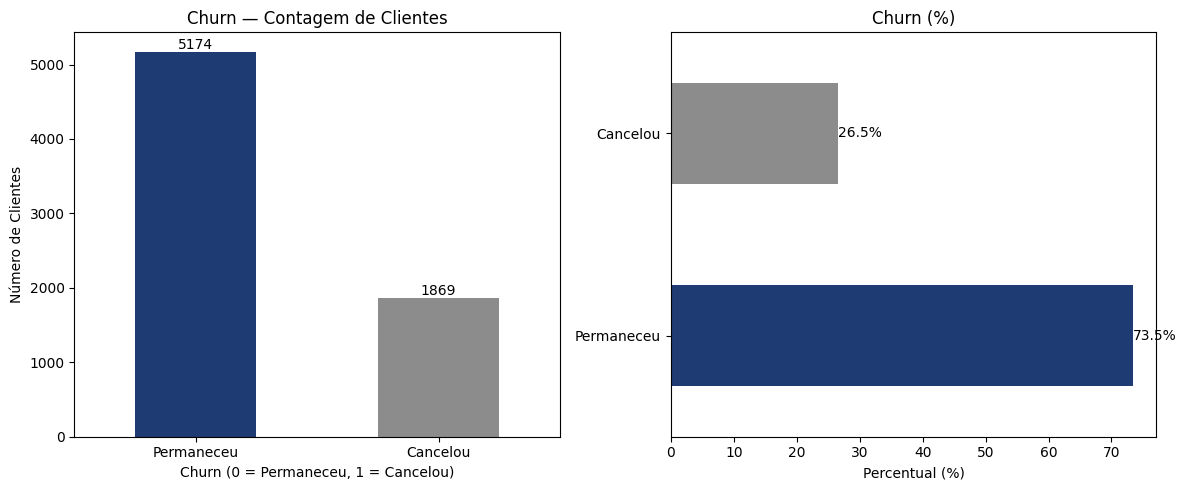

In [12]:

from numpy.random.mtrand import f
churn_cnt = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).mul(100)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Gráfico 1 — Contagem

ax = churn_cnt.plot(
    kind='bar',
    ax=axes[0],
    color=['#1F3B73', '#8C8C8C']
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.0f}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

axes[0].set_title('Churn — Contagem de Clientes')
axes[0].set_ylabel('Número de Clientes')
axes[0].set_xlabel('Churn (0 = Permaneceu, 1 = Cancelou)')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Permaneceu', 'Cancelou'], rotation=0)

# Gráfico 2

ax2 = churn_pct.plot(
    kind='barh',
    ax=axes[1],
    color=['#1F3B73', '#8C8C8C']
)

for p in ax2.patches:
    ax2.annotate(
        f'{p.get_width():.1f}%',
        (p.get_width(), p.get_y() + p.get_height()/2),
        ha='left', va='center'
    )

axes[1].set_title('Churn (%)')
axes[1].set_xlabel('Percentual (%)')
axes[1].set_ylabel('')
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['Permaneceu', 'Cancelou'])

plt.tight_layout()
plt.show()


In [16]:
churn_total = churn_cnt.sum()
churn_cancelados = churn_cnt[1] # Churn = 1 represents cancelled customers

# Cálculo da taxa
churn_pct_cancelados = (churn_cancelados / churn_total) * 100

# Exibindo com print
print("Total de clientes:", churn_total)
print("Clientes que cancelaram:", churn_cancelados)
print("Taxa de Churn: {:.2f}%".format(churn_pct_cancelados))

Total de clientes: 7043
Clientes que cancelaram: 1869
Taxa de Churn: 26.54%


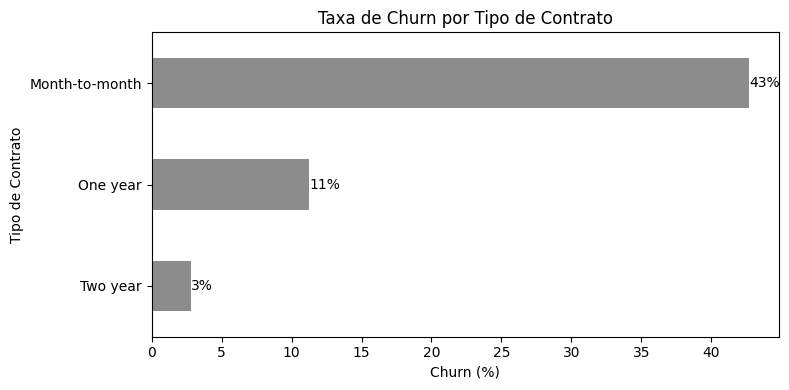

In [17]:
#  Gráfico 3 — Churn por Tipo de Contrato

churn_contrato = df.groupby('account_Contract')['Churn'].value_counts(normalize=True).unstack().mul(100)[1]

plt.figure(figsize=(8, 4))

ax = churn_contrato.sort_values().plot(
    kind='barh',
    color=['#8C8C8C']
)

plt.title('Taxa de Churn por Tipo de Contrato')
plt.xlabel('Churn (%)')
plt.ylabel('Tipo de Contrato')

for p in ax.patches:
    ax.annotate(
        f'{p.get_width():.0f}%',          # pega o comprimento da barra
        (p.get_width(), p.get_y() + p.get_height() / 2),  # x = comprimento da barra, y = meio da barra
        ha='left', va='center'
    )
plt.tight_layout()
plt.show()

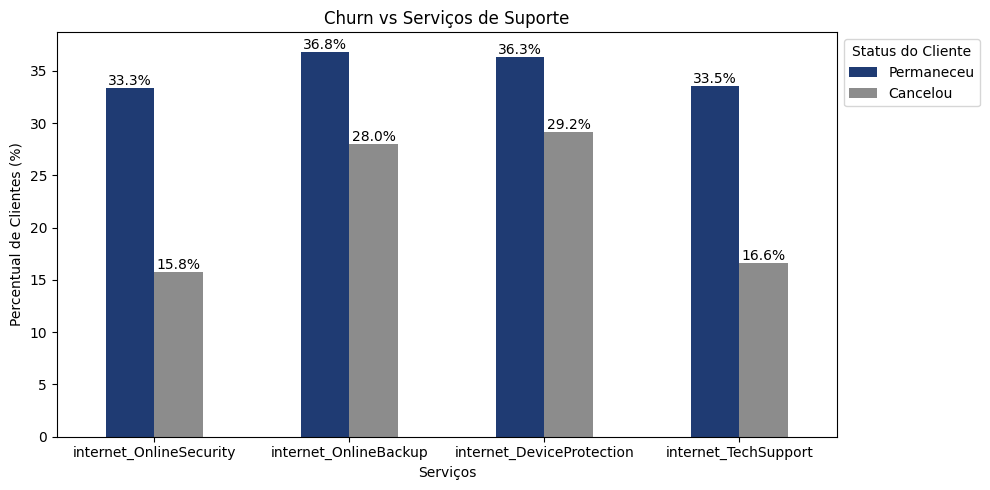

In [18]:
#Gráfico 4 — Churn vs Serviços de Suporte

# Serviços selecionados
servicos = [
    'internet_OnlineSecurity',
    'internet_OnlineBackup',
    'internet_DeviceProtection',
    'internet_TechSupport'
]

# Calculando churn médio por serviço (%)
churn_servicos = df.groupby('Churn')[servicos].mean().mul(100).T

# Plotando barras agrupadas
ax = churn_servicos.plot(
    kind='bar',
    figsize=(10,5),
    color=['#1F3B73', '#8C8C8C']
)

plt.title('Churn vs Serviços de Suporte')
plt.ylabel('Percentual de Clientes (%)')
plt.xlabel('Serviços')
plt.xticks(rotation=0)
plt.legend(['Permaneceu', 'Cancelou'], title='Status do Cliente', loc='upper left', bbox_to_anchor=(1,1))

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',  # corrigido
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.tight_layout()
plt.show()

<Figure size 800x500 with 0 Axes>

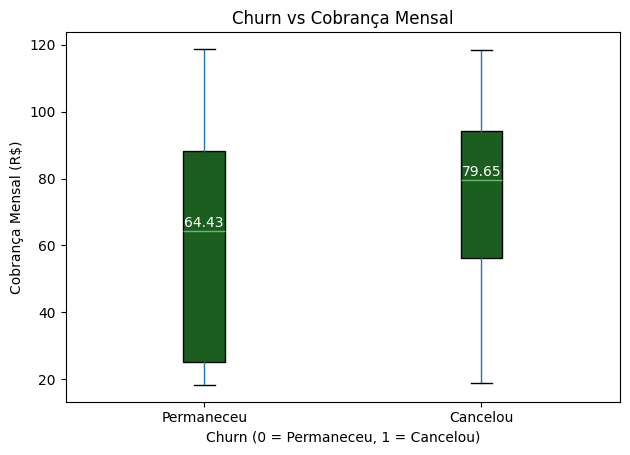

In [19]:
# Gráfico 5 — Churn vs Cobrança Mensal

plt.figure(figsize=(8,5))

# Boxplot de cobrança mensal por status de churn
df.boxplot(column='account_Charges_Monthly', by='Churn', grid=False, patch_artist=True,
           boxprops=dict(facecolor='#1B5E20'), medianprops=dict(color='#66BB6A'))

plt.title('Churn vs Cobrança Mensal')
plt.suptitle('')
plt.ylabel('Cobrança Mensal (R$)')
plt.xlabel('Churn (0 = Permaneceu, 1 = Cancelou)')
plt.xticks([1,2], ['Permaneceu', 'Cancelou'])

medians = df.groupby('Churn')['account_Charges_Monthly'].median().values
for i, median in enumerate(medians, start=1):
    plt.text(i, median + 1, f'{median:.2f}', ha='center', color='white')

plt.tight_layout()
plt.show()

#📄Relatorio Final

1️⃣ Proporção Geral de Churn

O que os dados revelam: A taxa de churn é de 26,54%, indicando que mais de 1 em cada 4 clientes cancelou o serviço.

Contexto: Esse percentual é elevado para empresas de receita recorrente, pois exige reposição constante da base apenas para manter estabilidade.

2️⃣ Churn por Tipo de Contrato

O que os dados revelam: Clientes com contrato mensal (month-to-month) apresentam maior taxa de cancelamento em comparação aos contratos anuais ou bienais.

Contexto: Contratos de curto prazo oferecem maior flexibilidade ao cliente, reduzindo barreiras para saída. Isso sugere menor vínculo e menor fidelização nesse grupo.

3️⃣ Churn por Tempo de Permanência (Tenure)

O que os dados revelam: Clientes com menor tempo de permanência concentram maior taxa de churn.

Contexto: Os primeiros meses de relacionamento parecem ser críticos. Isso pode indicar falhas no onboarding, desalinhamento de expectativa ou percepção inicial de valor insuficiente.

4️⃣ Churn por Serviços Contratados

O que os dados revelam: Clientes que possuem menos serviços adicionais tendem a cancelar mais. Já aqueles com maior número de serviços agregados apresentam menor churn.

Contexto: Quanto maior o nível de integração e dependência do serviço, maior o custo percebido de troca, o que favorece retenção.

5️⃣ Churn por Valor Mensal (Monthly Charges)

O que os dados revelam: Clientes com mensalidades mais altas demonstram tendência maior de cancelamento.

Contexto: O preço pode estar sendo percebido como alto em relação ao valor entregue, indicando sensibilidade a custo ou percepção de baixa vantagem competitiva.


🎯 Conclusão Final da Análise

A análise dos dados indica que o churn da TelecomX não é aleatório — ele apresenta padrões claros e segmentáveis.

Os principais pontos identificados foram:

Alta taxa geral de churn (26,54%)

Maior cancelamento em contratos mensais

Concentração de churn nos primeiros meses

Maior evasão entre clientes com menos serviços

Sensibilidade ao valor da mensalidade


📌 Conclusão estratégica:

A TelecomX precisa atuar principalmente em três frentes:

Retenção nos primeiros meses de contrato

Incentivo à migração para contratos mais longos

Aumento da percepção de valor (bundle de serviços e melhoria de experiência)

Se nenhuma ação for implementada, a empresa continuará operando com alto custo de aquisição para compensar perdas, reduzindo margem e previsibilidade de receita.

Por outro lado, como os padrões estão identificados, há forte potencial de aplicação de modelos preditivos de churn e estratégias segmentadas de retenção, o que pode reduzir significativamente a evasão no médio prazo.






# Analisando:

1️⃣ Proporção Geral de Churn

O que os dados revelam:
A taxa de churn é de 26,54%, indicando que mais de 1 em cada 4 clientes cancelou o serviço.

Contexto:
Esse percentual é elevado para empresas de receita recorrente, pois exige reposição constante da base apenas para manter estabilidade.

2️⃣ Churn por Tipo de Contrato

O que os dados revelam:
Clientes com contrato mensal (month-to-month) apresentam maior taxa de cancelamento em comparação aos contratos anuais ou bienais.

Contexto:
Contratos de curto prazo oferecem maior flexibilidade ao cliente, reduzindo barreiras para saída. Isso sugere menor vínculo e menor fidelização nesse grupo.

3️⃣ Churn por Tempo de Permanência (Tenure)

O que os dados revelam:
Clientes com menor tempo de permanência concentram maior taxa de churn.

Contexto:
Os primeiros meses de relacionamento parecem ser críticos. Isso pode indicar falhas no onboarding, desalinhamento de expectativa ou percepção inicial de valor insuficiente.

4️⃣ Churn por Serviços Contratados

O que os dados revelam:
Clientes que possuem menos serviços adicionais tendem a cancelar mais. Já aqueles com maior número de serviços agregados apresentam menor churn.

Contexto:
Quanto maior o nível de integração e dependência do serviço, maior o custo percebido de troca, o que favorece retenção.

5️⃣ Churn por Valor Mensal (Monthly Charges)

O que os dados revelam:
Clientes com mensalidades mais altas demonstram tendência maior de cancelamento.

Contexto:
O preço pode estar sendo percebido como alto em relação ao valor entregue, indicando sensibilidade a custo ou percepção de baixa vantagem competitiva.


🎯 Conclusão Final da Análise

A análise dos dados indica que o churn da TelecomX não é aleatório — ele apresenta padrões claros e segmentáveis.

Os principais pontos identificados foram:

Alta taxa geral de churn (26,54%)

Maior cancelamento em contratos mensais

Concentração de churn nos primeiros meses

Maior evasão entre clientes com menos serviços

Sensibilidade ao valor da mensalidade


📌 Conclusão estratégica:

A TelecomX precisa atuar principalmente em três frentes:

Retenção nos primeiros meses de contrato

Incentivo à migração para contratos mais longos

Aumento da percepção de valor (bundle de serviços e melhoria de experiência)

Se nenhuma ação for implementada, a empresa continuará operando com alto custo de aquisição para compensar perdas, reduzindo margem e previsibilidade de receita.

Por outro lado, como os padrões estão identificados, há forte potencial de aplicação de modelos preditivos de churn e estratégias segmentadas de retenção, o que pode reduzir significativamente a evasão no médio prazo.